# **Homework 2 Phoneme Classification**

* Slides: https://docs.google.com/presentation/d/1v6HkBWiJb8WNDcJ9_-2kwVstxUWml87b9CnA16Gdoio/edit?usp=sharing
* Kaggle: https://www.kaggle.com/c/ml2022spring-hw2
* Video: TBA


In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## Download Data
Download data from google drive, then unzip it.

You should have
- `libriphone/train_split.txt`
- `libriphone/train_labels`
- `libriphone/test_split.txt`
- `libriphone/feat/train/*.pt`: training feature<br>
- `libriphone/feat/test/*.pt`:  testing feature<br>

after running the following block.

> **Notes: if the google drive link is dead, you can download the data directly from [Kaggle](https://www.kaggle.com/c/ml2022spring-hw2/data) and upload it to the workspace**


### Download train/test metadata

### Preparing Data
拼接维度，有些tricky

In [3]:
'''**Helper functions to pre-process the training data from raw MFCC features of each utterance.**

A phoneme may span several frames and is dependent to past and future frames. \
Hence we concatenate neighboring phonemes for training to achieve higher accuracy. The **concat_feat** function concatenates past and future k frames (total 2k+1 = n frames), and we predict the center frame.

Feel free to modify the data preprocess functions, but **do not drop any frame** (if you modify the functions, remember to check that the number of frames are the same as mentioned in the slides)
'''
import os
import random
import pandas as pd
import torch
from tqdm import tqdm

def load_feat(path):
    feat = torch.load(path)
    return feat

def shift(x, n):
    if n < 0:
        left = x[0].repeat(-n, 1)
        right = x[:n]

    elif n > 0:
        right = x[-1].repeat(n, 1)
        left = x[n:]
    else:
        return x

    return torch.cat((left, right), dim=0)


#拼接函数
def concat_feat(x, concat_n):
    assert concat_n % 2 == 1 # n must be odd
    if concat_n < 2:
        return x
    seq_len, feature_dim = x.size(0), x.size(1)
    x = x.repeat(1, concat_n) 
    x = x.view(seq_len, concat_n, feature_dim).permute(1, 0, 2) # concat_n, seq_len, feature_dim
    mid = (concat_n // 2)
    for r_idx in range(1, mid+1):
        x[mid + r_idx, :] = shift(x[mid + r_idx], r_idx)
        x[mid - r_idx, :] = shift(x[mid - r_idx], -r_idx)

    return x.permute(1, 0, 2).view(seq_len, concat_n * feature_dim)

#数据处理函数 将训练集合划一部分为训练集一部分为测试集
def preprocess_data(split, feat_dir, phone_path, concat_nframes, train_ratio=0.8, train_val_seed=1337):
    class_num = 41 # NOTE: pre-computed, should not need change
    mode = 'train' if (split == 'train' or split == 'val') else 'test'

    label_dict = {}
    if mode != 'test':
      phone_file = open(os.path.join(phone_path, f'{mode}_labels.txt')).readlines()

      for line in phone_file:
          line = line.strip('\n').split(' ')
          label_dict[line[0]] = [int(p) for p in line[1:]]

    if split == 'train' or split == 'val':
        # split training and validation data
        usage_list = open(os.path.join(phone_path, 'train_split.txt')).readlines()
        random.seed(train_val_seed)
        random.shuffle(usage_list)
        percent = int(len(usage_list) * train_ratio)
        usage_list = usage_list[:percent] if split == 'train' else usage_list[percent:]
    elif split == 'test':
        usage_list = open(os.path.join(phone_path, 'test_split.txt')).readlines()
    else:
        raise ValueError('Invalid \'split\' argument for dataset: PhoneDataset!')

    usage_list = [line.strip('\n') for line in usage_list]
    print('[Dataset] - # phone classes: ' + str(class_num) + ', number of utterances for ' + split + ': ' + str(len(usage_list)))

    max_len = 3000000
    X = torch.empty(max_len, 39 * concat_nframes)
    if mode != 'test':
      y = torch.empty(max_len, dtype=torch.long)

    idx = 0
    for i, fname in tqdm(enumerate(usage_list)):
        feat = load_feat(os.path.join(feat_dir, mode, f'{fname}.pt'))
        cur_len = len(feat)
        feat = concat_feat(feat, concat_nframes)
        if mode != 'test':
          label = torch.LongTensor(label_dict[fname])

        X[idx: idx + cur_len, :] = feat
        if mode != 'test':
          y[idx: idx + cur_len] = label

        idx += cur_len

    X = X[:idx, :]
    if mode != 'test':
      y = y[:idx]

    print(f'[INFO] {split} set')
    print(X.shape)
    if mode != 'test':
      print(y.shape)
      return X, y
    else:
      return X


## Define Dataset

In [4]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

#dataset本质是将传入参数中的量转换为：x向量-y标量的形式返回（重写官方库的dataset类成员函数、__getitem__类返回所需）
class LibriDataset(Dataset):
    def __init__(self, X, y=None):
        self.data = X    #X为data,y为label
        if y is not None:
            self.label = torch.LongTensor(y)
        else:
            self.label = None

    def __getitem__(self, idx):
        if self.label is not None:
            return self.data[idx], self.label[idx]   #最终返回x向量与y标量
        else:
            return self.data[idx]

    def __len__(self):
        return len(self.data)


## Define Model

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#单层神经元模块一个线形层+激活层（激活层必不可少，因为肯定不是线性的）
class BasicBlock(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(BasicBlock, self).__init__()

        #sequential为了构建一个自动化的传播逻辑定义结构之后不用再在forward函数中一层一层手动传播
        self.block = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        x = self.block(x) #直接调用定义好的block传入一个入口参数就行
        return x

#调用前面定义好的BasicBlock类basicBlock看作一个封装好的单层模块
class Classifier(nn.Module):
    def __init__(self, input_dim, output_dim=41, hidden_layers=1, hidden_dim=256):
        super(Classifier, self).__init__()

        #1.定义自动化的圣经网络结构
        #2.直接使用先定义好的BasicBlock模块
        #3.内部的BasicBlock输入输出维度不变：是为了多过几次提取特征
        #重新组合、非线性引入、
        self.fc = nn.Sequential(
            BasicBlock(input_dim, hidden_dim),
            *[BasicBlock(hidden_dim, hidden_dim) for _ in range(hidden_layers)],#输入输出维度不变:解读深层特征组合
            nn.Linear(hidden_dim, output_dim) #输出层不过非线性的激活函数
        )
            

    def forward(self, x):
        x = self.fc(x)
        return x



'''
class MyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(MyRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

    def forward(self, x):
        x, _ = self.rnn(x)
        return x

class Classifier(nn.Module):
    def __init__(self, input_dim, output_dim=41, hidden_layers=1, hidden_dim=256, concat_nframes=11):
        super(Classifier, self).__init__()
        
        self.concat_nframes = concat_nframes  # 记录拼接的帧数 (11)

        # 1. RNN 时序层 (放在最前面，直接处理原始 39 维 MFCC 特征)
        # 输入: [Batch, 11, 39]，输出: [Batch, 11, 64]
        self.rnn = MyRNN(input_size=39, hidden_size=64, num_layers=1)
            
        # 2. 后置 MLP 特征提取 (处理 RNN 输出的 64 维时序特征)
        self.fc = nn.Sequential(
            BasicBlock(64, hidden_dim),
            *[BasicBlock(hidden_dim, hidden_dim) for _ in range(hidden_layers)],
        )
        
        # 3. 分类头 (输入维度为 MLP 的输出维度 hidden_dim)
        self.linear = nn.Linear(hidden_dim, output_dim) 

    def forward(self, x):
        # x 的原始形状: [Batch, 429] (即 11 * 39)
        batch_size = x.size(0)
        
        # 第一步：将拍扁的 429 维还原为 11 帧的序列 [Batch, 11, 39]
        x = x.view(batch_size, self.concat_nframes, -1)
        
        # 第二步：送入 RNN 提取时序特征 [Batch, 11, 64]
        x = self.rnn(x)
        
        # 第三步：取最后一个时间步的特征 [Batch, 64]
        x = x[:, -1, :]
        
        # 第四步：送入 MLP 提取深层特征 [Batch, 256]
        x = self.fc(x)
        
        # 第五步：输出分类结果 [Batch, 41]
        x = self.linear(x)
        
        return x
        '''

'\nclass MyRNN(nn.Module):\n    def __init__(self, input_size, hidden_size, num_layers):\n        super(MyRNN, self).__init__()\n        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)\n\n    def forward(self, x):\n        x, _ = self.rnn(x)\n        return x\n\nclass Classifier(nn.Module):\n    def __init__(self, input_dim, output_dim=41, hidden_layers=1, hidden_dim=256, concat_nframes=11):\n        super(Classifier, self).__init__()\n        \n        self.concat_nframes = concat_nframes  # 记录拼接的帧数 (11)\n\n        # 1. RNN 时序层 (放在最前面，直接处理原始 39 维 MFCC 特征)\n        # 输入: [Batch, 11, 39]，输出: [Batch, 11, 64]\n        self.rnn = MyRNN(input_size=39, hidden_size=64, num_layers=1)\n            \n        # 2. 后置 MLP 特征提取 (处理 RNN 输出的 64 维时序特征)\n        self.fc = nn.Sequential(\n            BasicBlock(64, hidden_dim),\n            *[BasicBlock(hidden_dim, hidden_dim) for _ in range(hidden_layers)],\n        )\n        \n        # 3. 分类头 (输入维度为 MLP 的输出维度 hidden_dim)\n  

## Hyper-parameters

In [6]:
# data prarameters
concat_nframes = 23            # the number of frames to concat with, n must be odd (total 2k+1 = n frames)
train_ratio = 0.8               # the ratio of data used for training, the rest will be used for validation

# training parameters
seed = 114                        # random seed  为防止不确定性
batch_size = 1026                # batch size
num_epoch =51                  # the number of training epoch
learning_rate = 0.01          # learning rate
model_path = './model.ckpt'     # the path where the checkpoint will be saved

# model parameters
input_dim = 39 * concat_nframes # the input dim of the model, you should not change the value
hidden_layers = 1               # the number of hidden layers
hidden_dim = 256                # the hidden dim

## Prepare dataset and model

In [7]:
import gc

# preprocess data
#/kaggle/input/competitions/ml2022spring-hw2
train_X, train_y = preprocess_data(split='train', feat_dir='/kaggle/input/competitions/ml2022spring-hw2/libriphone/libriphone/feat', phone_path='/kaggle/input/competitions/ml2022spring-hw2/libriphone/libriphone', concat_nframes=concat_nframes, train_ratio=train_ratio)
val_X, val_y = preprocess_data(split='val', feat_dir='/kaggle/input/competitions/ml2022spring-hw2/libriphone/libriphone/feat', phone_path='/kaggle/input/competitions/ml2022spring-hw2/libriphone/libriphone', concat_nframes=concat_nframes, train_ratio=train_ratio)

# get dataset   train与val分别构建
train_set = LibriDataset(train_X, train_y)
val_set = LibriDataset(val_X, val_y)

# remove raw feature to save memory
del train_X, train_y, val_X, val_y
gc.collect()



# get dataloader  一样分别构建
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True) 
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

[Dataset] - # phone classes: 41, number of utterances for train: 3428


3428it [00:38, 89.58it/s]


[INFO] train set
torch.Size([2116368, 897])
torch.Size([2116368])
[Dataset] - # phone classes: 41, number of utterances for val: 858


858it [00:09, 88.07it/s]


[INFO] val set
torch.Size([527790, 897])
torch.Size([527790])


In [8]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'DEVICE: {device}')

DEVICE: cpu


In [9]:
import numpy as np

#fix seed
def same_seeds(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
    np.random.seed(seed)  
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [10]:
# fix random seed
same_seeds(seed)

#学习率优化余弦退火+warming up(手动实现线性预热，为退火做准备)
from torch.optim.lr_scheduler import CosineAnnealingLR,LinearLR,SequentialLR #线性预热+余弦退火

# create model, define a loss function, and optimizer
model = Classifier(input_dim=input_dim, hidden_layers=hidden_layers, hidden_dim=hidden_dim).to(device)





import torch
import numpy as np
from collections import Counter

# 1. 统计你的训练集标签分布 (替换为你自己的数据集变量名)
labels = [label for _, label in train_set] 
class_counts = Counter(labels)
num_classes = len(class_counts) # 你的类别总数 (例如 41)
total_samples = len(labels)

# 2. 计算每个类别的权重
class_weights = torch.zeros(num_classes)
for cls_id, count in class_counts.items():
    # 使用平方根倒数法，平衡大类和小类
    class_weights[cls_id] = np.sqrt(total_samples / count)

# 3. 将权重移动到 GPU (非常重要，否则会和模型不在同一设备报错)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate,betas=(0.95, 0.999),weight_decay=0.01)



warmup_epoch=int(num_epoch*0.1)  #warm up步数为总步数的10%
warmup_scheduler=LinearLR(optimizer,start_factor=0.1,total_iters=warmup_epoch)

cosine_scheduler=CosineAnnealingLR(optimizer,T_max=num_epoch-warmup_epoch,eta_min=0)


scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler,cosine_scheduler],milestones=[warmup_epoch])  #T_max与训练轮次严格一致

In [11]:
print(next(model.parameters()).device)

cpu


## Training

100%|██████████| 515/515 [00:09<00:00, 55.67it/s]


[001/051] Train Acc: 0.578558 Loss: 1.410507 | Val Acc: 0.602287 loss: 1.333510
saving model with acc 0.602


100%|██████████| 515/515 [00:09<00:00, 56.39it/s]


[002/051] Train Acc: 0.616078 Loss: 1.280365 | Val Acc: 0.623473 loss: 1.254172
saving model with acc 0.623


100%|██████████| 515/515 [00:09<00:00, 55.94it/s]


...

[049/051] Train Acc: 0.658279 Loss: 1.140511 | Val Acc: 0.653851 loss: 1.156908


100%|██████████| 515/515 [00:11<00:00, 46.61it/s]


[050/051] Train Acc: 0.658677 Loss: 1.140848 | Val Acc: 0.629894 loss: 1.256528


100%|██████████| 515/515 [00:10<00:00, 47.70it/s]


[051/051] Train Acc: 0.658671 Loss: 1.140130 | Val Acc: 0.648262 loss: 1.183514


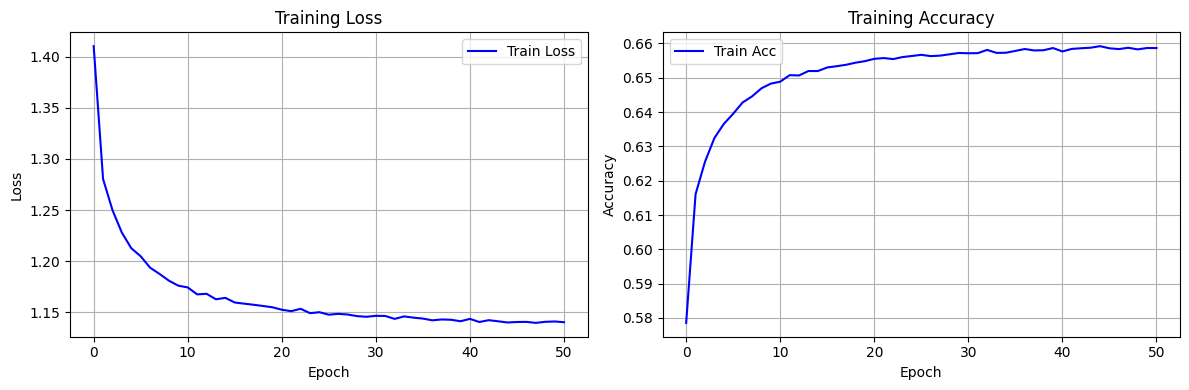

In [12]:
import matplotlib.pyplot as plt



plt_train_loss=[]
plt_train_acc=[]
best_acc = 0.0
for epoch in range(num_epoch):
    train_acc = 0.0  #训练准确而率  
    train_loss = 0.0
    val_acc = 0.0   #验证准确率   验证集是从总训练集上分割一部分
    val_loss = 0.0



#可视化
    
    
    # training
    model.train() # set the model to training mode
    for i, batch in enumerate(tqdm(train_loader)):  #tqdm进度条库对train_loader
                                    #enumerate 返回”当前序号，当前数据“
        features, labels = batch   #batch返回一个元组两个值，通过赋值给feat lab
                                   #feature=batch[0] labels=batch[1]
        
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad() 
        outputs = model(features) 
        
        loss = criterion(outputs, labels)
        
        loss.backward() 
        optimizer.step()
        scheduler.step() 
        #max会返回两个变量：值与索引但只要索引,_作为占位符接收值后丢弃
        _, train_pred = torch.max(outputs, 1) # get the index of the class with the highest probability
        train_acc += (train_pred.detach() == labels.detach()).sum().item()
        train_loss += loss.item()

    #计算本epoch的平均值，追加到外层列表
    avg_train_loss=train_loss/len(train_loader)
    avg_train_acc=train_acc/len(train_set)
    plt_train_loss.append(avg_train_loss)
    plt_train_acc.append(avg_train_acc)
    
    # validation
    if len(val_set) > 0:
        model.eval() # set the model to evaluation mode
        with torch.no_grad():
            for i, batch in enumerate(tqdm(val_loader)):
                features, labels = batch
                features = features.to(device)
                labels = labels.to(device)
                outputs = model(features)
                
                loss = criterion(outputs, labels) 
                
                _, val_pred = torch.max(outputs, 1) 
                val_acc += (val_pred.cpu() == labels.cpu()).sum().item() # get the index of the class with the highest probability
                val_loss += loss.item()


            print('[{:03d}/{:03d}] Train Acc: {:3.6f} Loss: {:3.6f} | Val Acc: {:3.6f} loss: {:3.6f}'.format(
                epoch + 1, num_epoch, train_acc/len(train_set), train_loss/len(train_loader), val_acc/len(val_set), val_loss/len(val_loader)
            ))

            # if the model improves, save a checkpoint at this epoch
            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), model_path)
                print('saving model with acc {:.3f}'.format(best_acc/len(val_set)))
    else:
        print('[{:03d}/{:03d}] Train Acc: {:3.6f} Loss: {:3.6f}'.format(
            epoch + 1, num_epoch, train_acc/len(train_set), train_loss/len(train_loader)
        ))




#这一步保存训练好的模型参数以便后续测试的时候load参数，保存到磁盘上
# if not validating, save the last epoch
if len(val_set) == 0:
    torch.save(model.state_dict(), model_path)   #保存训练参数在此路径（路径名在超参数中）
    print('saving model at last epoch')





#绘制
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(plt_train_loss, label='Train Loss', color='blue')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(plt_train_acc, label='Train Acc', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
del train_loader, val_loader  #删除已经保存内容防止内存爆
gc.collect()

NameError: name 'train_loader' is not defined

## Testing
Create a testing dataset, and load model from the saved checkpoint.

In [14]:
# load data
#将测试文件也要同样方法预处理处理一遍
test_X = preprocess_data(split='test', feat_dir='/kaggle/input/competitions/ml2022spring-hw2/libriphone/libriphone/feat', phone_path='/kaggle/input/competitions/ml2022spring-hw2/libriphone/libriphone', concat_nframes=concat_nframes)
test_set = LibriDataset(test_X, None) #只有x传给自定义的dataset，对应的在实现dataset的时候要考虑到第二个参数不存在的情况
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

[Dataset] - # phone classes: 41, number of utterances for test: 1078


1078it [00:17, 62.37it/s]

[INFO] test set
torch.Size([646268, 897])


In [15]:
# load model
#模型最重要的是权重内容而不是形式

#先写一个完全形式结构一样的模型然后再将权重load进来
model = Classifier(input_dim=input_dim, hidden_layers=hidden_layers, hidden_dim=hidden_dim).to(device)

#将之前保存的参数从路径中加载进来
#原参数被存储为字典，默认语法：model.load_state_dict(state_dict, strict=True)
#torch.load是将参数字典从硬盘加载到内存中来
model.load_state_dict(torch.load(model_path))





'''state_dict 是一个字典，它的 Key（键名）包含了模型中每一层的名称（例如 'linear1.weight', 'linear1.bias'）。
当你调用 load_state_dict() 时，PyTorch 会拿着字典里的 Key，去你刚刚定义好的空壳模型（model）里寻找名字完全一样的层。
'''

<All keys matched successfully>

Make prediction. 开始测试


In [19]:
test_acc = 0.0
test_lengths = 0
pred = np.array([], dtype=np.int32)

model.eval()
with torch.no_grad():#测试的时候不需要记录梯度（又不更新参数）
    for i, batch in enumerate(tqdm(test_loader)):
        features = batch
        features = features.to(device)

        outputs = model(features)   #直接将处理好的特征传进model(已经事先加载)

        _, test_pred = torch.max(outputs, 1) # get the index of the class with the highest probability
        pred = np.concatenate((pred, test_pred.cpu().numpy()), axis=0)


100%|██████████| 630/630 [00:09<00:00, 67.36it/s]


Write prediction to a CSV file.

After finish running this block, download the file `prediction.csv` from the files section on the left-hand side and submit it to Kaggle.

In [20]:
with open('prediction.csv', 'w') as f:
    f.write('Id,Class\n')
    for i, y in enumerate(pred):
        f.write('{},{}\n'.format(i, y))